In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_intdiv(smiles_list):

    if len(smiles_list) < 2:
        return np.nan  

    mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]
    valid_mols = [mol for mol in mols if mol is not None]

    if len(valid_mols) < 2:
        return np.nan


    fps = [AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024) for mol in valid_mols]

    distances = []
    for i in range(len(fps)):
        for j in range(i + 1, len(fps)):
            sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            distances.append(1 - sim)

    return np.mean(distances) 


def smiles_list_to_combined_fingerprint(smiles_list, radius=2, nBits=1024):
    """
    将一个前体组合（如 ['CCO', 'c1ccccc1']）合并为一个 pseudo-molecule，
    并生成 Morgan 指纹。
    """
    # 使用 '+' 连接多个分子（RDKit 支持）
    combined_smi = '.'.join(smiles_list)
    mol = Chem.MolFromSmiles(combined_smi)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
    return fp

def calculate_IntDivp(precursor_paths, radius=2, nBits=1024):
    """
    计算一组前体路径的 Internal Diversity (IntDivp)
    
    Args:
        precursor_paths: List[List[str]]，例如 [['A','B'], ['A','C'], ['D']]
        radius: ECFP 指纹半径，默认 2（ECFP4）
        nBits: 指纹长度，默认 1024
    
    Returns:
        float: IntDivp 值，若无法计算返回 np.nan
    """
    if len(precursor_paths) < 2:
        return np.nan  # 至少需要两个路径才能计算多样性

    # Step 1: 转换为指纹
    fps = []
    for path in precursor_paths:
        fp = smiles_list_to_combined_fingerprint(path, radius=radius, nBits=nBits)
        if fp is not None:
            fps.append(fp)

    if len(fps) < 2:
        return 0


    distances = []
    for i in range(len(fps)):
        for j in range(i + 1, len(fps)):
            sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            distances.append(1 - sim)  

    return np.mean(distances) 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_kde_hist(data1, data2, data3, color1="#0e9131",color2= "#3775C6",color3= "#ea9311",
                  label1='Beamsearch', label2='Top-K Sample', label3='Top-P Sample',
                  label_fontsize=14, tick_fontsize=14, legend_fontsize=14):

    data1 = pd.Series(data1)
    data2 = pd.Series(data2)
    data3 = pd.Series(data3)

    fig, ax_density = plt.subplots(figsize=(9, 6))


    sns.kdeplot(data1, color=color1, linestyle='-', lw=2, ax=ax_density, label=label1)
    sns.kdeplot(data2, color=color2, linestyle='-', lw=2, ax=ax_density, label=label2)
    sns.kdeplot(data3, color=color3, linestyle='-', lw=2, ax=ax_density, label=label3)
    ax_density.axvline(data1.mean(), color=color1, linestyle='--', lw=1.8, alpha=0.8)
    ax_density.axvline(data2.mean(), color=color2, linestyle='--', lw=1.8, alpha=0.8)
    ax_density.axvline(data3.mean(), color=color3, linestyle='--', lw=1.8, alpha=0.8)


    ax_density.set_xlabel('IntDivp', fontsize=label_fontsize)
    ax_density.set_ylabel('Density', fontsize=label_fontsize)
    

    ax_density.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    
    ax_density.legend(fontsize=legend_fontsize, loc='best', frameon=True)
    
    ax_density.grid(alpha=0.3, linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax_density


In [ ]:
def plot_validity_violin(valid_data_list, labels, colors=None,
                         ylabel='Valid & Unique Ratio', title='Validity Comparison',
                         label_fontsize=14, tick_fontsize=14, legend_fontsize=14,
                         show_stats=True, ylim=(0, 1.05),
                         inner='box', show_mean=True, width=0.8):

    if colors is None:
        colors = sns.color_palette("husl", len(labels)).as_hex()
    if len(colors) < len(labels):
        colors = colors + ['#999999'] * (len(labels) - len(colors))
    
    fig, ax = plt.subplots(figsize=(9, 6))
    
    data_long = []
    for i, (v, lbl) in enumerate(zip(valid_data_list, labels)):
        v_clean = pd.Series(v).dropna()
        for val in v_clean:
            data_long.append({'Method': lbl, 'Valid': val, 'Color': colors[i]})
    df_long = pd.DataFrame(data_long)
    
    sns.violinplot(data=df_long, x='Method', y='Valid', 
                   palette=colors, inner=inner, width=width,
                   cut=0,  # 不延伸超出数据范围
                   linewidth=1.5, ax=ax)
    
    if show_mean:
        for i, (v, lbl) in enumerate(zip(valid_data_list, labels)):
            v_clean = pd.Series(v).dropna()
            if len(v_clean) > 0:
                mean_val = v_clean.mean()
                ax.scatter(i, mean_val, 
                          marker='D', color="#DA3F4C", s=60, zorder=10,
                          edgecolor='white', linewidth=1.5)
    
    ax.set_xlabel(xlabel=None)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_ylim(ylim)
    ax.grid(alpha=0.3, linestyle='--', axis='y')

    if show_stats:
        for i, (v, lbl, clr) in enumerate(zip(valid_data_list, labels, colors), 1):
            v_clean = pd.Series(v).dropna()
            if len(v_clean) > 0:
                mean_val = v_clean.mean()
                std_val = v_clean.std()
                ax.text(i - 1, ylim[1] * 0.99, f'{mean_val:.3f}±{std_val:.3f}', 
                       ha='center', va='top', fontsize=tick_fontsize, 
                       bbox=dict(boxstyle='round', facecolor=clr, alpha=0.25, edgecolor='none'))
    
    plt.tight_layout()
    plt.show()
    
    if show_stats:
        print(f"📊 {title} Statistics:")
        for v, lbl in zip(valid_data_list, labels):
            v_clean = pd.Series(v).dropna()
            if len(v_clean) > 0:
                median_val = v_clean.median()
                q1, q3 = v_clean.quantile(0.25), v_clean.quantile(0.75)
                print(f"{lbl:12s}: Mean={v_clean.mean():.4f}, Std={v_clean.std():.4f}, "
                      f"Median={median_val:.4f}, IQR=[{q1:.4f}, {q3:.4f}], N={len(v_clean)}")
    
    return fig, ax

In [8]:
def plot_validity_boxplot(valid_data_list, labels, colors=None,
                          ylabel='Valid Ratio', title='Validity Comparison',
                          label_fontsize=14, tick_fontsize=12, legend_fontsize=11,
                          show_stats=True, ylim=(0, 1.05)):

    # 颜色设置
    if colors is None:
        colors = sns.color_palette("husl", len(labels)).as_hex()
    if len(colors) < len(labels):
        colors = colors + ['#999999'] * (len(labels) - len(colors))
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(9, 6))
    
    # 绘制箱线图
    bp = ax.boxplot(valid_data_list, labels=labels, patch_artist=True, 
                    widths=0.6, showmeans=True, meanline=True,
                    boxprops=dict(alpha=0.7), medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(linestyle='--', alpha=0.7),
                    capprops=dict(color='black', lw=1))
    
    # 自定义箱体颜色
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # 美化均值线（红色虚线）
    for mean_line in bp['means']:
        mean_line.set_color('red')
        mean_line.set_linestyle('--')
        mean_line.set_linewidth(2)
    
    # 坐标轴设置
    #ax.set_xlabel('Method', fontsize=label_fontsize, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_ylim(ylim)
    ax.grid(alpha=0.3, linestyle='--', axis='y')
    #ax.set_title(title, fontsize=label_fontsize, fontweight='bold')
    
    # 添加统计标注（均值±标准差）
    if show_stats:
        for i, (v, lbl, clr) in enumerate(zip(valid_data_list, labels, colors), 1):
            v_clean = pd.Series(v).dropna()
            if len(v_clean) > 0:
                mean_val = v_clean.mean()
                std_val = v_clean.std()
                ax.text(i, ylim[1] * 0.92, f'{mean_val:.3f}±{std_val:.3f}', 
                       ha='center', va='top', fontsize=tick_fontsize, 
                       bbox=dict(boxstyle='round', facecolor=clr, alpha=0.2, edgecolor='none'))
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    if show_stats:
        print(f"📊 {title} Statistics:")
        for v, lbl in zip(valid_data_list, labels):
            v_clean = pd.Series(v).dropna()
            if len(v_clean) > 0:
                print(f"{lbl:12s}: Mean={v_clean.mean():.4f}, Std={v_clean.std():.4f}, N={len(v_clean)}")
    
    return fig, ax

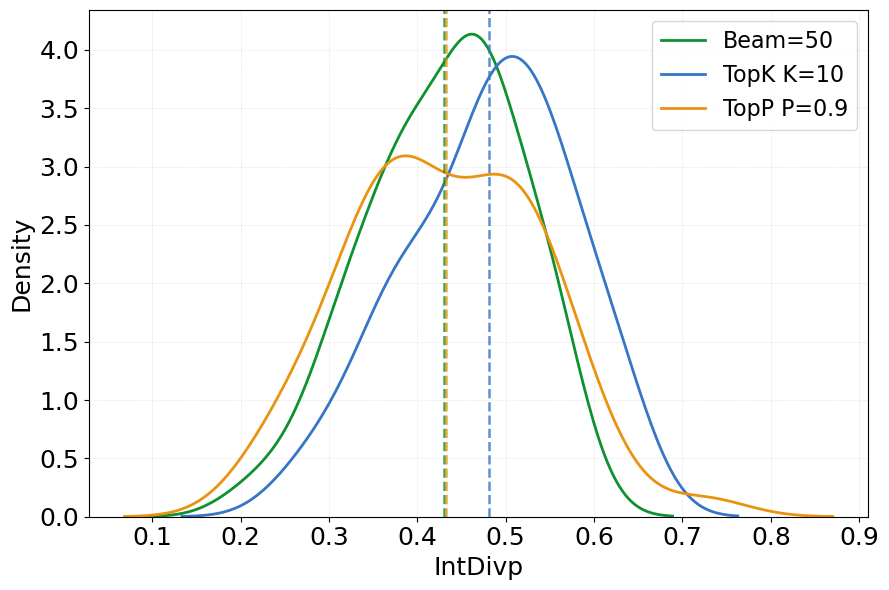

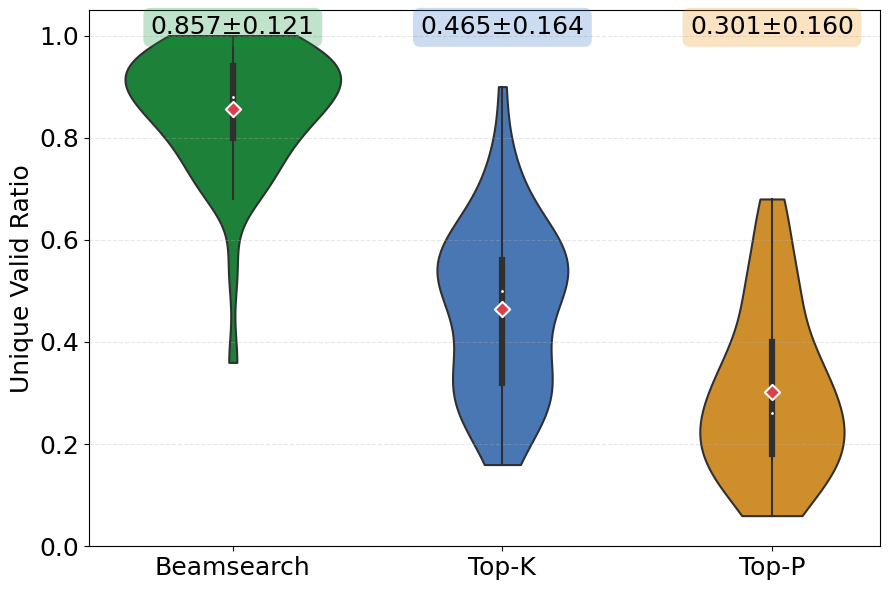

📊 Validity Comparison Statistics:
Beamsearch  : Mean=0.8570, Std=0.1213, Median=0.8800, IQR=[0.8000, 0.9400], N=53
Top-K       : Mean=0.4653, Std=0.1637, Median=0.5000, IQR=[0.3200, 0.5600], N=53
Top-P       : Mean=0.3011, Std=0.1605, Median=0.2600, IQR=[0.1800, 0.4000], N=53


(<Figure size 900x600 with 1 Axes>, <Axes: ylabel='Unique Valid Ratio'>)

In [ ]:
df_beam = pd.read_csv('benchmark/IntDivp_beam_more_50.csv',index_col=0)
df_beam['Valid'] = df_beam['Num_Routes']/50
df_topk = pd.read_csv('benchmark/IntDivp_topk_more_k10_50.csv',index_col=0)
df_topk['Valid'] = df_topk['Num_Routes']/50
df_topp = pd.read_csv('benchmark/IntDivp_topp_more_p0.9_50.csv',index_col=0)
df_topp['Valid'] = df_topp['Num_Routes']/50

# 提取 IntDivp 列
intdivp_beam = df_beam['IntDivp']
intdivp_topk = df_topk['IntDivp']
#intdivp_top_50 = df_topk_50['IntDivp']
intdivp_topp = df_topp['IntDivp']
# 绘图
plot_kde_hist(intdivp_beam, intdivp_topk, intdivp_topp, label1='Beam=50', label2='TopK K=10', label3='TopP P=0.9', label_fontsize=18, tick_fontsize=18, legend_fontsize=16)

#plot_validity_boxplot([df_beam['Valid'], df_topk['Valid'], df_topp['Valid']], ['Beamsearch', 'Top-K', 'Top-P'], ['#0e9131', '#3775C6', "#d78914"], label_fontsize=14, tick_fontsize=12)

plot_validity_violin(
    [df_beam['Valid'], df_topk['Valid'], df_topp['Valid']], 
    ['Beamsearch', 'Top-K', 'Top-P'], 
    ['#0e9131', '#3775C6', "#ea9311"], 
    ylabel='Unique Valid Ratio',
    label_fontsize=18, 
    tick_fontsize=18,
    inner='box',       
    show_mean=True     
)

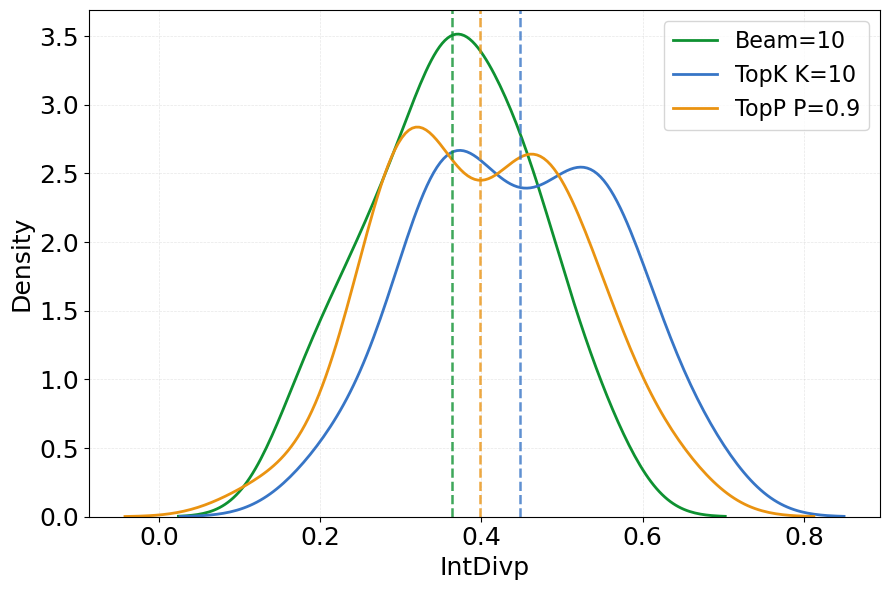

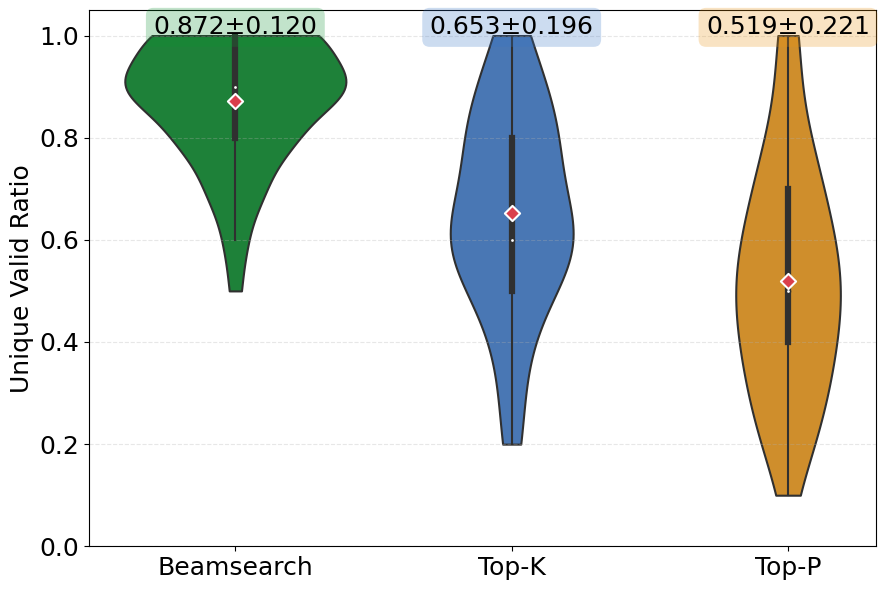

📊 Validity Comparison Statistics:
Beamsearch  : Mean=0.8717, Std=0.1199, Median=0.9000, IQR=[0.8000, 1.0000], N=53
Top-K       : Mean=0.6528, Std=0.1957, Median=0.6000, IQR=[0.5000, 0.8000], N=53
Top-P       : Mean=0.5189, Std=0.2211, Median=0.5000, IQR=[0.4000, 0.7000], N=53


(<Figure size 900x600 with 1 Axes>, <Axes: ylabel='Unique Valid Ratio'>)

In [12]:
df_beam = pd.read_csv('benchmark/IntDivp_beam_more_10.csv',index_col=0)
df_beam['Valid'] = df_beam['Num_Routes']/10
df_topk = pd.read_csv('benchmark/IntDivp_topk_more_k10_10.csv',index_col=0)
df_topk['Valid'] = df_topk['Num_Routes']/10
df_topp = pd.read_csv('benchmark/IntDivp_topp_more_p0.9_10.csv',index_col=0)
df_topp['Valid'] = df_topp['Num_Routes']/10

# 提取 IntDivp 列
intdivp_beam = df_beam['IntDivp']
intdivp_topk = df_topk['IntDivp']
#intdivp_top_50 = df_topk_50['IntDivp']
intdivp_topp = df_topp['IntDivp']
# 绘图
plot_kde_hist(intdivp_beam, intdivp_topk, intdivp_topp, label1='Beam=10', label2='TopK K=10', label3='TopP P=0.9', label_fontsize=18, tick_fontsize=18, legend_fontsize=16)

#plot_validity_boxplot([df_beam['Valid'], df_topk['Valid'], df_topp['Valid']], ['Beamsearch', 'Top-K', 'Top-P'], ['#0e9131', '#3775C6', "#d78914"], label_fontsize=14, tick_fontsize=12)

plot_validity_violin(
    [df_beam['Valid'], df_topk['Valid'], df_topp['Valid']], 
    ['Beamsearch', 'Top-K', 'Top-P'], 
    ['#0e9131', '#3775C6', "#ea9311"], 
    ylabel='Unique Valid Ratio',
    label_fontsize=18, 
    tick_fontsize=18,
    inner='box',        # 内部显示迷你箱线图
    show_mean=True      # 显示红色均值点
)

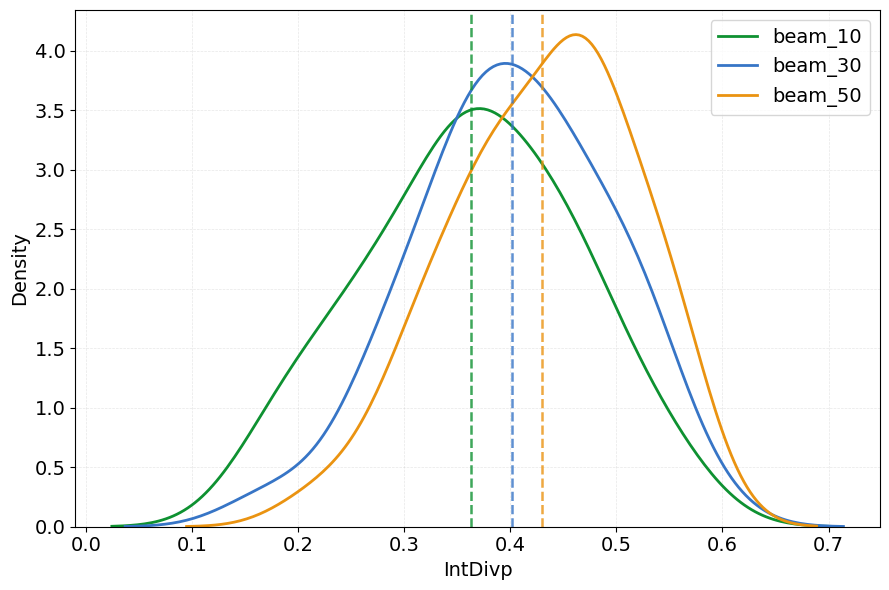

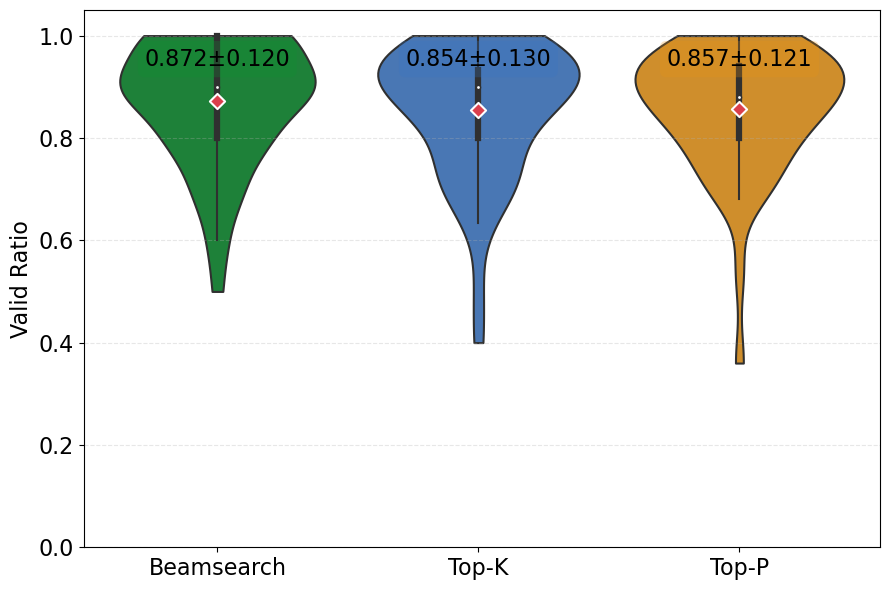

📊 Validity Comparison Statistics:
Beamsearch  : Mean=0.8717, Std=0.1199, Median=0.9000, IQR=[0.8000, 1.0000], N=53
Top-K       : Mean=0.8541, Std=0.1298, Median=0.9000, IQR=[0.8000, 0.9333], N=53
Top-P       : Mean=0.8570, Std=0.1213, Median=0.8800, IQR=[0.8000, 0.9400], N=53


(<Figure size 900x600 with 1 Axes>, <Axes: ylabel='Valid Ratio'>)

In [90]:


df_beam_10 = pd.read_csv('benchmark/IntDivp_beam_more_10.csv')
df_beam_10_ = df_beam_10['IntDivp']
df_beam_10['Valid'] = df_beam_10['Num_Routes']/10

df_beam_30 = pd.read_csv('benchmark/IntDivp_beam_more_30.csv')
df_beam_30_ = df_beam_30['IntDivp']
df_beam_30['Valid'] = df_beam_30['Num_Routes']/30

df_beam_50 = pd.read_csv('benchmark/IntDivp_beam_more_50.csv')
df_beam_50_ = df_beam_50['IntDivp']
df_beam_50['Valid'] = df_beam_50['Num_Routes']/50
plot_kde_hist(df_beam_10_ , df_beam_30_ , df_beam_50_, label1='beam_10', label2='beam_30', label3='beam_50')
plot_validity_violin(
    [df_beam_10['Valid'], df_beam_30['Valid'], df_beam_50['Valid']], 
    ['Beamsearch', 'Top-K', 'Top-P'], 
    ['#0e9131', '#3775C6', "#ea9311"], 
    label_fontsize=16, 
    tick_fontsize=16,
    inner='box',        # 内部显示迷你箱线图
    show_mean=True      # 显示红色均值点
)

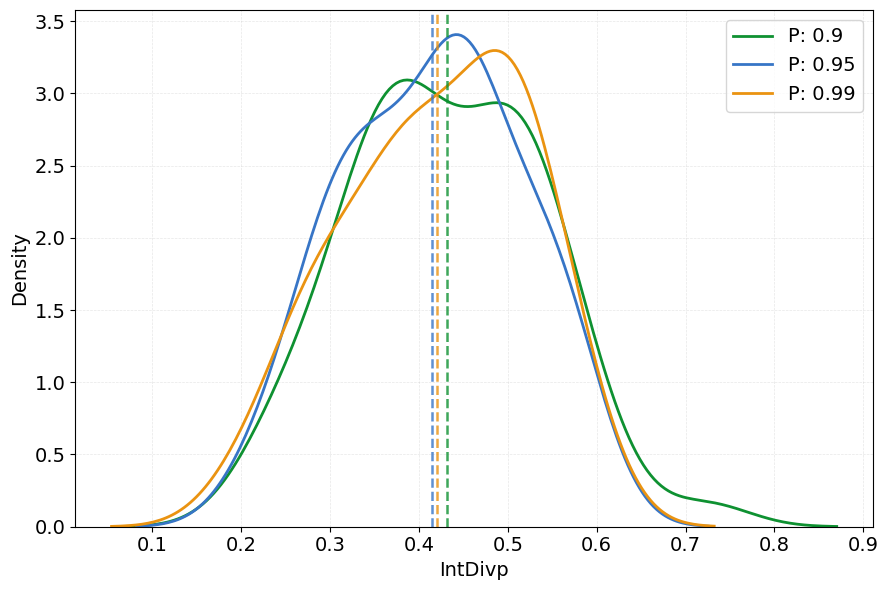

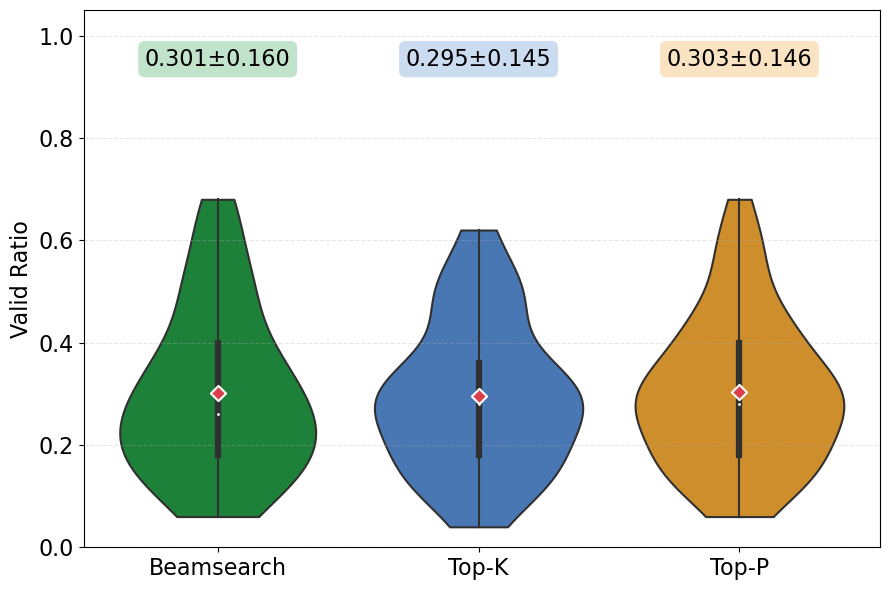

📊 Validity Comparison Statistics:
Beamsearch  : Mean=0.3011, Std=0.1605, Median=0.2600, IQR=[0.1800, 0.4000], N=53
Top-K       : Mean=0.2947, Std=0.1448, Median=0.2800, IQR=[0.1800, 0.3600], N=53
Top-P       : Mean=0.3034, Std=0.1458, Median=0.2800, IQR=[0.1800, 0.4000], N=53


(<Figure size 900x600 with 1 Axes>, <Axes: ylabel='Valid Ratio'>)

In [85]:
df_topp_90 = pd.read_csv('benchmark/IntDivp_topp_more_p0.9_50.csv')
df_topp_90_ = df_topp_90['IntDivp']
df_topp_90['Valid'] = df_topp_90['Num_Routes']/50

df_topp_95 = pd.read_csv('benchmark/IntDivp_topp_more_p0.95_50.csv')
df_topp_95_ = df_topp_95['IntDivp']
df_topp_95['Valid'] = df_topp_95['Num_Routes']/50

df_topp_99 = pd.read_csv('benchmark/IntDivp_topp_more_p0.99_50.csv')
df_topp_99_ = df_topp_99['IntDivp']
df_topp_99['Valid'] = df_topp_99['Num_Routes']/50
plot_kde_hist(df_topp_90_ , df_topp_95_ , df_topp_99_ , label1='P: 0.9', label2='P: 0.95', label3='P: 0.99')
plot_validity_violin(
    [df_topp_90['Valid'], df_topp_95['Valid'], df_topp_99['Valid']], 
    ['Beamsearch', 'Top-K', 'Top-P'], 
    ['#0e9131', '#3775C6', "#ea9311"], 
    label_fontsize=16, 
    tick_fontsize=16,
    inner='box',        # 内部显示迷你箱线图
    show_mean=True      # 显示红色均值点
)